In [1]:
import numpy as np
import torch
import importlib

# make numpy arrays display with fewer decimals throughout the notebook
np.set_printoptions(precision=4, suppress=True)

from Face import face_inference
from Audio import audio_inference

# reload modules in case they were edited since kernel start
importlib.reload(face_inference)
importlib.reload(audio_inference)

from Face.face_inference import load_face_model, get_face_emotion_from_image
from Audio.audio_inference import get_audio_emotion_vector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


face_model = load_face_model("./working/best_resemotenet_model.pth")

def predict_emotion(image_path, audio_path):
    face_vec = get_face_emotion_from_image(image_path, face_model)
    audio_vec = get_audio_emotion_vector(audio_path)
    return face_vec, audio_vec


In [2]:
# demonstrate converting the returned vectors into a label->probability dict
labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

face_vec, audio_vec = predict_emotion(
    # "test_data/happy-jj-1.jpeg",
    # "test_data/1001_IOM_HAP_XX.wav"
    # "./test_data/fear_padte.jpeg",
    # "./test_data/fear-ajp.wav"
    "test_data/sad.jpeg",
    "test_data/sad-ajp-1.wav"
    # "test_data/angry-1.jpeg",
    # "test_data/1001_DFA_ANG_XX.wav"
)

# convert numpy floats to native Python floats to avoid np.float32/64 wrappers
face_probs = {lbl: float(prob.round(3)) for lbl, prob in zip(labels, face_vec)}
audio_probs = {lbl: float(prob.round(3)) for lbl, prob in zip(labels, audio_vec)}

print("Face probabilities:", face_probs)
print("Audio probabilities:", audio_probs)


c:\Users\anagh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Face probabilities: {'angry': 0.04399999976158142, 'disgust': 0.27000001072883606, 'fear': 0.029999999329447746, 'happy': 0.027000000700354576, 'neutral': 0.0, 'sad': 0.4429999887943268, 'surprise': 0.1850000023841858}
Audio probabilities: {'angry': 0.036, 'disgust': 0.123, 'fear': 0.443, 'happy': 0.021, 'neutral': 0.018, 'sad': 0.358, 'surprise': 0.0}


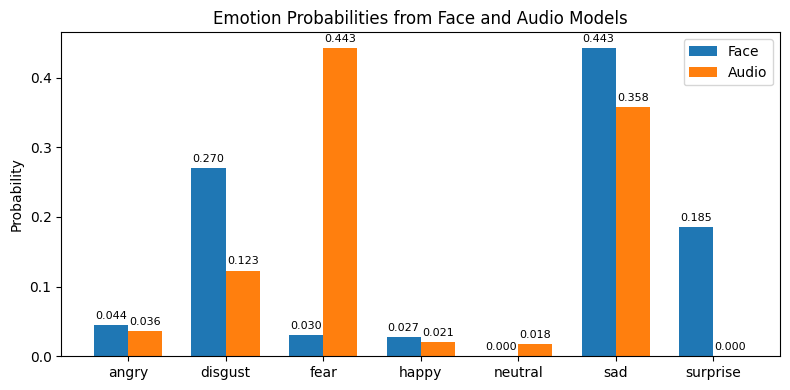

In [3]:

# visualization of the probability vectors
import matplotlib.pyplot as plt
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
face_bars = ax.bar(x - width/2, face_vec, width, label='Face')
audio_bars = ax.bar(x + width/2, audio_vec, width, label='Audio')

ax.set_ylabel('Probability')
ax.set_title('Emotion Probabilities from Face and Audio Models')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for bar in face_bars + audio_bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from scipy.stats import entropy

labels = ['angry','disgust','fear','happy','neutral','sad','surprise']

def depression_score(face_vec, audio_vec):
    f = np.array(face_vec)
    a = np.array(audio_vec)

    fused = 0.6*f + 0.4*a  # weighted fusion

    sad = fused[labels.index('sad')]
    happy = fused[labels.index('happy')]
    surprise = fused[labels.index('surprise')]

    flatness = entropy(fused)

    score = (
        2.0 * sad
        - 1.5 * happy
        - 0.5 * surprise
        + 0.3 * flatness
    )

    return score

In [5]:
score = depression_score(face_vec, audio_vec)

if score > 0.6:
    print("High Depression Risk")
elif score > 0.3:
    print("Moderate Risk")
else:
    print("Low Risk")

High Depression Risk
